# Finding the centres of three red spherical balls

This notebook loads `IMG_2710.jpeg`, identifies the red balls and calculates their centre coordinates in pixels.

The workflow is:

1. load the image;
2. convert it from RGB to HSV colour space;
3. threshold the red hue ranges;
4. clean the binary mask;
5. use a distance transform to find one seed inside each ball;
6. separate the touching balls and calculate their centres;
7. plot and save the result.

Image coordinates use the usual convention: the origin $(0,0)$ is at the **top-left**, $x$ increases to the right and $y$ increases downwards.

## 1. Import the libraries

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

## 2. Load and display the image

Image size: 3024 × 4032 pixels


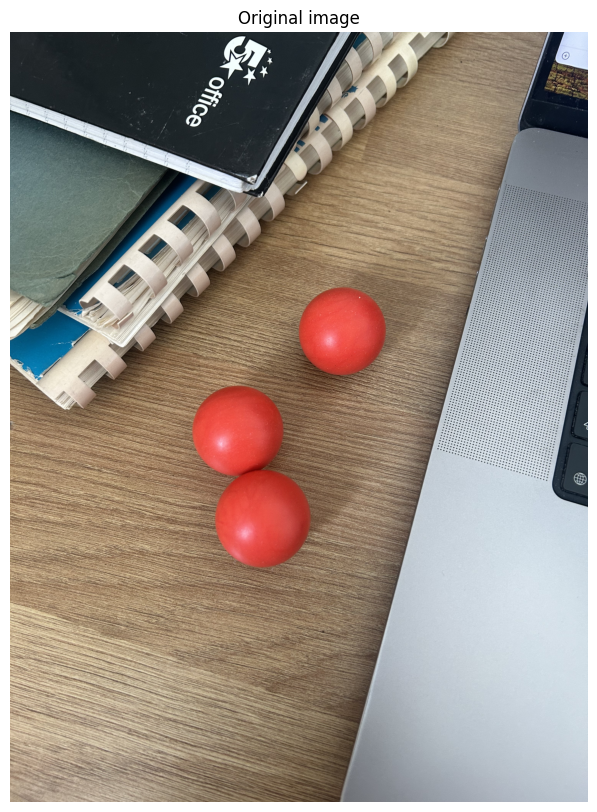

In [2]:
image_path = Path("IMG_2710.jpeg")

if not image_path.exists():
    raise FileNotFoundError(
        f"Could not find {image_path.resolve()}. "
        "Place IMG_2710.jpeg in the same folder as this notebook."
    )

# OpenCV loads colour images in BGR order. Convert to RGB for plotting.
image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise ValueError(f"OpenCV could not read {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]

print(f"Image size: {width} × {height} pixels")

plt.figure(figsize=(8, 10))
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")
plt.show()

## 3. Select the red pixels

HSV separates colour (**hue**) from saturation and brightness. Red wraps around the ends of OpenCV's hue scale, so two hue intervals are combined.

The saturation and value limits reject grey, white and very dark objects. If a different photograph has unusual lighting, these thresholds may need adjustment.

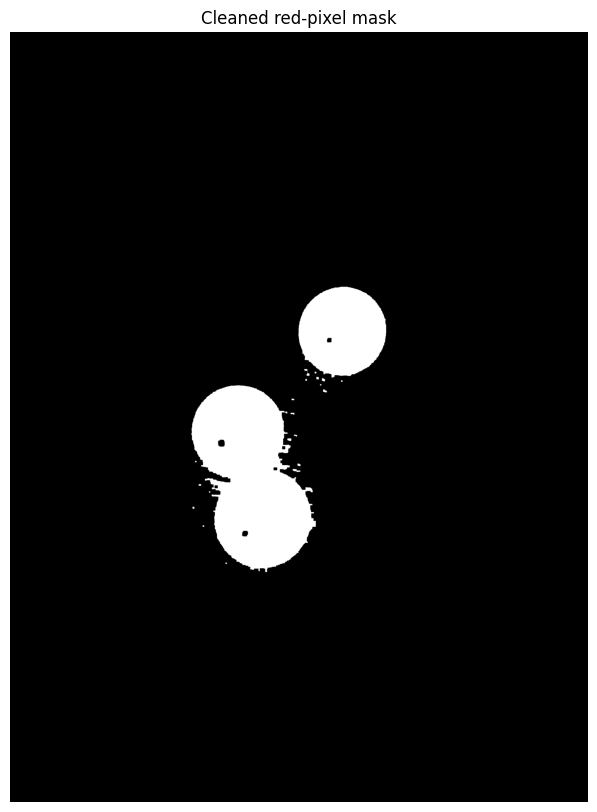

In [3]:
hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

# Red occupies both the low and high ends of OpenCV's hue scale (0–179).
lower_red_1 = np.array([0, 100, 80], dtype=np.uint8)
upper_red_1 = np.array([12, 255, 255], dtype=np.uint8)
lower_red_2 = np.array([168, 100, 80], dtype=np.uint8)
upper_red_2 = np.array([179, 255, 255], dtype=np.uint8)

mask_1 = cv2.inRange(hsv, lower_red_1, upper_red_1)
mask_2 = cv2.inRange(hsv, lower_red_2, upper_red_2)
red_mask = cv2.bitwise_or(mask_1, mask_2)

# Remove isolated pixels and fill small gaps in the balls.
opening_kernel = np.ones((7, 7), dtype=np.uint8)
closing_kernel = np.ones((15, 15), dtype=np.uint8)
red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, opening_kernel)
red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, closing_kernel)

plt.figure(figsize=(8, 10))
plt.imshow(red_mask, cmap="gray")
plt.title("Cleaned red-pixel mask")
plt.axis("off")
plt.show()

## 4. Find one seed inside each ball

Two balls touch in this photograph, so connected components alone would merge them. A distance transform assigns every red pixel its distance from the nearest background pixel. Each approximately circular ball produces a strong local maximum near its centre.

In [4]:
distance = cv2.distanceTransform(red_mask, cv2.DIST_L2, 5)

# Find well-separated local maxima. The filter size should be smaller than the
# ball diameter but larger than small variations caused by highlights.
local_maximum = ndi.maximum_filter(distance, size=301)
peak_mask = (distance == local_maximum) & (distance > 100)
peak_labels, number_of_peaks = ndi.label(peak_mask)

seed_centres = []
for label_number in range(1, number_of_peaks + 1):
    y_pixels, x_pixels = np.where(peak_labels == label_number)
    strongest = np.argmax(distance[y_pixels, x_pixels])
    seed_centres.append((x_pixels[strongest], y_pixels[strongest]))

seed_centres = np.asarray(seed_centres, dtype=float)

if len(seed_centres) != 3:
    raise RuntimeError(
        f"Expected 3 ball seeds but found {len(seed_centres)}. "
        "Adjust the HSV thresholds, peak distance threshold or maximum-filter size."
    )

print("Initial distance-transform seeds:")
print(seed_centres)

Initial distance-transform seeds:
[[1803. 1516.]
 [1252. 2041.]
 [1380. 2498.]]


## 5. Refine the three centres

Each red pixel is assigned to its nearest seed. The centre of each resulting region is then calculated from the mean $x$ and $y$ pixel positions. This separates the two touching balls without requiring a visible gap between them.

In [5]:
y_pixels, x_pixels = np.nonzero(red_mask)
red_coordinates = np.column_stack((x_pixels, y_pixels))

# Squared Euclidean distance from every red pixel to each seed.
distance_to_seeds = np.sum(
    (red_coordinates[:, None, :] - seed_centres[None, :, :]) ** 2,
    axis=2,
)
region_assignment = np.argmin(distance_to_seeds, axis=1)

centres = []
equivalent_radii = []
for region_number in range(3):
    region_pixels = red_coordinates[region_assignment == region_number]
    centre_x, centre_y = region_pixels.mean(axis=0)
    radius = np.sqrt(len(region_pixels) / np.pi)
    centres.append((centre_x, centre_y))
    equivalent_radii.append(radius)

centres = np.asarray(centres)
equivalent_radii = np.asarray(equivalent_radii)

# Sort from top to bottom to give the balls a repeatable numbering.
order = np.argsort(centres[:, 1])
centres = centres[order]
equivalent_radii = equivalent_radii[order]

print("Detected ball centres (origin at top-left):")
for ball_number, ((centre_x, centre_y), radius) in enumerate(
    zip(centres, equivalent_radii), start=1
):
    print(
        f"Ball {ball_number}: x = {centre_x:.1f} px, "
        f"y = {centre_y:.1f} px, equivalent radius ≈ {radius:.1f} px"
    )

Detected ball centres (origin at top-left):
Ball 1: x = 1737.2 px, y = 1569.1 px, equivalent radius ≈ 232.1 px
Ball 2: x = 1194.3 px, y = 2086.1 px, equivalent radius ≈ 240.6 px
Ball 3: x = 1320.1 px, y = 2534.5 px, equivalent radius ≈ 266.1 px


## 6. Display the detected centres

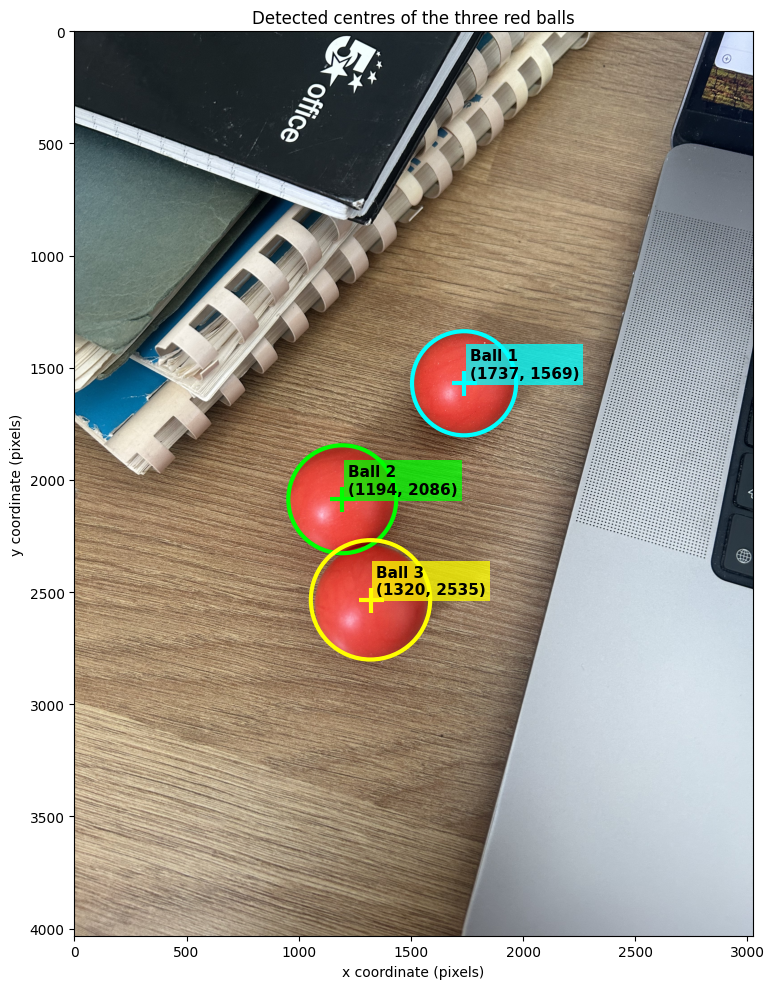

In [6]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(image_rgb)

colours = ["cyan", "lime", "yellow"]
for ball_number, ((centre_x, centre_y), radius, colour) in enumerate(
    zip(centres, equivalent_radii, colours), start=1
):
    circle = plt.Circle(
        (centre_x, centre_y),
        radius,
        fill=False,
        color=colour,
        linewidth=3,
    )
    ax.add_patch(circle)
    ax.plot(centre_x, centre_y, marker="+", color=colour, markersize=18, markeredgewidth=3)
    ax.text(
        centre_x + 25,
        centre_y - 25,
        f"Ball {ball_number}\n({centre_x:.0f}, {centre_y:.0f})",
        color="black",
        fontsize=11,
        weight="bold",
        bbox={"facecolor": colour, "alpha": 0.75, "edgecolor": "none", "pad": 3},
    )

ax.set_title("Detected centres of the three red balls")
ax.set_xlim(0, width)
ax.set_ylim(height, 0)
ax.set_xlabel("x coordinate (pixels)")
ax.set_ylabel("y coordinate (pixels)")
fig.tight_layout()
plt.show()

## 7. Save the annotated result

In [7]:
output_path = Path("IMG_2710_centres_detected.png")
fig.savefig(output_path, dpi=180, bbox_inches="tight")
print("Saved annotated image as:", output_path.resolve())

Saved annotated image as: /Users/ianeames/Library/CloudStorage/Dropbox-fluidboss/Ian Eames/teaching/Mathematics_Physics/Lecture2/JupyterLabs/IMG_2710_centres_detected.png


## Exercises

1. Change the HSV thresholds and observe how the mask changes.
2. Try the method on a photograph containing balls of a different colour.
3. Convert the centre coordinates from pixels to physical units using an object of known length in the image.
4. Calculate the distances between the three ball centres.
5. Investigate how image perspective affects the apparent ball radii.